<a href="https://colab.research.google.com/github/sammatiphugate/sammatiphugate/blob/main/Copy_of_Regression_ANN_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load the data from CSV
file_name = "USA_Housing.csv"
df = pd.read_csv(file_name)

In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
X = df.iloc[:, :-2]  # All columns except two columns, :-2 means you're selecting all columns except the last two.
y = df.iloc[:, -2]   # The Price column, -2: selects the column that is second from the end.

In [ ]:
'''
# Step 3: Scale the features
scaler = MinMaxScaler()
#scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
'''

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Step 5: Define the ANN model
'''
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
model.add(Dense(8, activation='relu'))  # Second hidden layer
model.add(Dense(1, activation='linear'))  # Output layer
'''


model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # No activation function for regression output


C:\Users\Santanu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 6: Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Step 7: Train the model
#loss is the output of your loss function, which in your case is 'mean_squared_error' (MSE).
history = model.fit(X_train, y_train, epochs=30, batch_size=8, validation_split=0.1, verbose=0)

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1623886397440.0000 - mae: 1226124.5000 - val_loss: 1650036834304.0000 - val_mae: 1232929.7500
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1610604085248.0000 - mae: 1220291.7500 - val_loss: 1632591282176.0000 - val_mae: 1226602.2500
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1609321021440.0000 - mae: 1218801.7500 - val_loss: 1589222178816.0000 - val_mae: 1210997.6250
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1546440278016.0000 - mae: 1198126.5000 - val_loss: 1515022974976.0000 - val_mae: 1184020.3750
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1492313309184.0000 - mae: 1178482.3750 - val_loss: 1410252406784.0000 - val_mae: 1144866.7500
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1354981572608.0000 - mae: 1124006.8750 - val_loss: 1276377038848.0000 - val_mae: 1092627.8750
Epoch 7/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1233248321536.00

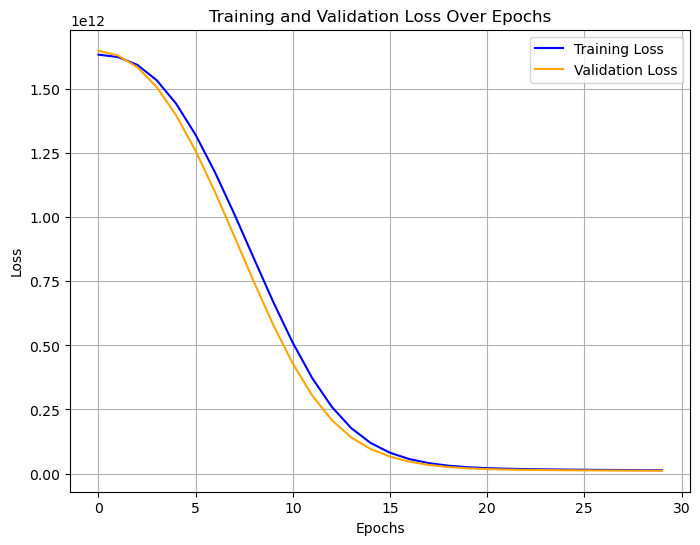

In [ ]:
# Step 10: Plot Training and Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

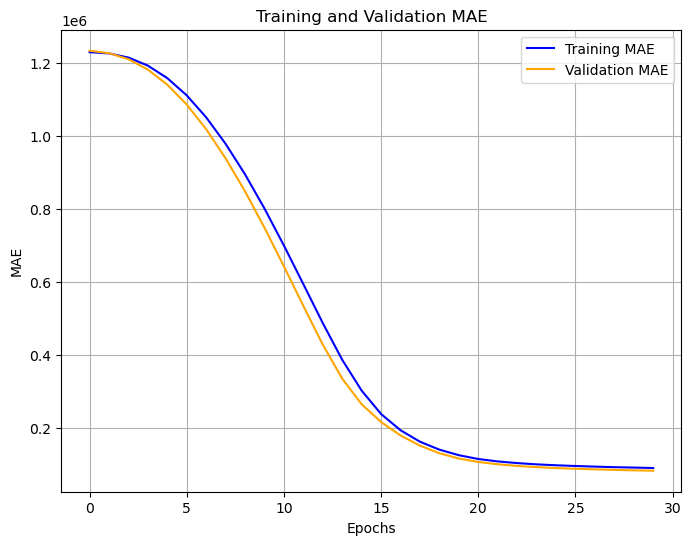

In [ ]:
# Step 10: Plot Training and Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['mae'], label='Training MAE', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
plt.title("Training and Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 8: Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss}")
print(f"Mean Absolute Error: {mae}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12246984704.0000 - mae: 88006.6172 
Test Loss: 12198431744.0
Mean Absolute Error: 86888.0078125


In [ ]:
# Step 9: Make predictions
predictions = model.predict(X_test)
#print("Predictions:", predictions)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# Step 10: Calculate additional metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 12198431359.51
Root Mean Squared Error (RMSE): 110446.51
R-squared (R²): 0.90


In [ ]:
predictions_total = model.predict(X_scaled)
df['Prediction'] = predictions_total

print(df[['Price', 'Prediction']])

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step
             Price   Prediction
0     1.059034e+06  1195793.500
1     1.505891e+06  1493895.875
2     1.058988e+06  1247793.625
3     1.260617e+06  1098243.875
4     6.309435e+05   794751.750
...            ...          ...
4995  1.060194e+06  1044271.250
4996  1.482618e+06  1387841.375
4997  1.030730e+06  1154396.875
4998  1.198657e+06  1226124.125
4999  1.298950e+06  1278884.125

[5000 rows x 2 columns]


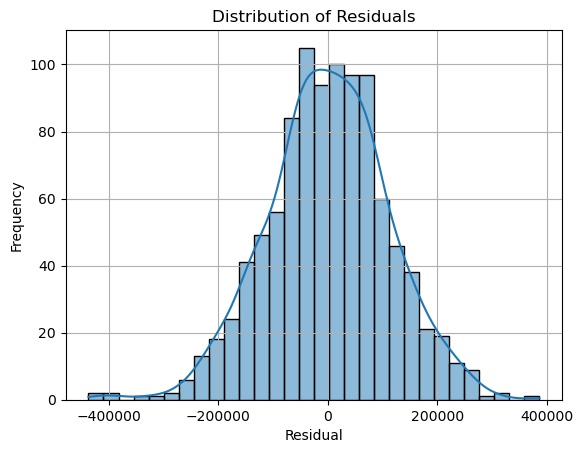

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - predictions.flatten()

sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



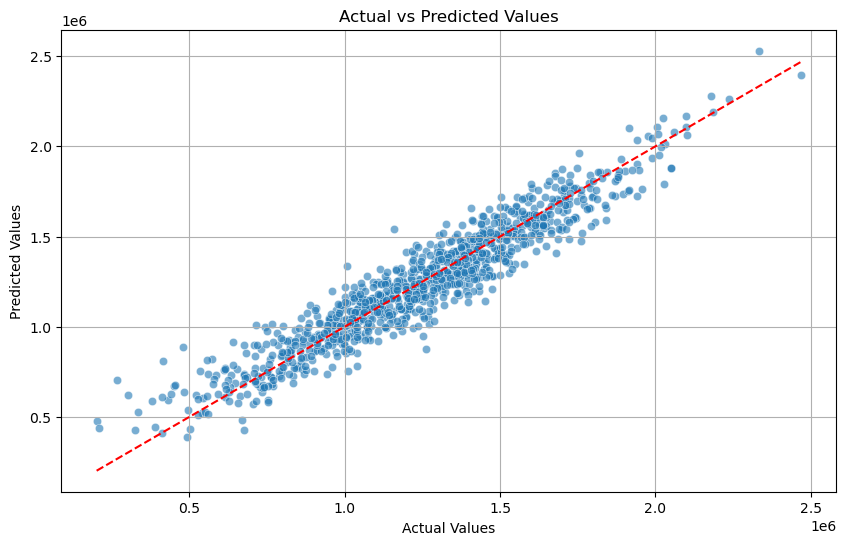

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions.flatten(), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # reference line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

### Well Done!

In [ ]:
# Import PySpark
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Import TensorFlow/Keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 1: Start Spark Session
spark = SparkSession.builder.appName("HousePricePrediction").getOrCreate()

# Step 2: Load Data
df = spark.read.csv("USA_Housing.csv", header=True, inferSchema=True)
df = df.dropna()

# Step 3: Rename target column
df = df.withColumnRenamed("Price", "label")

# Step 4: Assemble Features
feature_cols = ["Avg_Area_Income", "Avg_Area_House_Age", "Avg_Area_Number_of_Rooms",
                "Avg_Area_Number_of_Bedrooms", "Area_Population"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_vector = assembler.transform(df)

# Step 5: Scale Features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# Step 6: Convert to Pandas for Keras
pandas_df = df_scaled.select("scaledFeatures", "label").toPandas()
X = np.array(pandas_df["scaledFeatures"].tolist())
y = np.array(pandas_df["label"])

# Step 7: Build Keras Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

# Step 8: Evaluate Model
loss = model.evaluate(X, y)
print(f"Model Loss: {loss}")

# Step 9: Predict Sample
predictions = model.predict(X[:5])
print("Sample Predictions:", predictions)


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `Avg`.` Area Income` cannot be resolved. Did you mean one of the following? [`Avg`.` Area Income`, `Avg`.` Area House Age`, `Avg`.` Area Number of Rooms`, `Avg`.` Area Number of Bedrooms`, `Area Population`, `Price`, `Address`].